# Dementia Risk Prediction - Phase 1 (Non-Medical Model) -|- Team TriNeura

In [54]:
# -----------------------------
# 1. Imports
# -----------------------------
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# XGBoost
try:
    from xgboost import XGBClassifier
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost"])
    from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [55]:
# -----------------------------
# 2. Load Dataset
# -----------------------------
data_path = "Dementia Prediction Dataset.csv"

if not os.path.exists(data_path):
    raise FileNotFoundError("Dataset file not found.")

df = pd.read_csv(data_path)
print("Dataset shape:", df.shape)

print("\nPreview:")
display(df.head())

Dataset shape: (195196, 1024)

Preview:


,NACCID,NACCADC,PACKET,FORMVER,VISITMO,VISITDAY,VISITYR,NACCVNUM,NACCAVST,NACCNVST,...,NPATGAM1,NPATGAM2,NPATGAM3,NPATGAM4,NPATGAM5,NPATGFRN,NPATGFR1,NPATGFR2,NPATGFR3,NPATGFR4
0,NACC002909,186,I,3.0,12,28,2022,1,2,2,...,-4,-4,-4,-4,-4,-4,-4,-4,-4,-4
1,NACC002909,186,F,3.0,1,23,2024,2,2,2,...,-4,-4,-4,-4,-4,-4,-4,-4,-4,-4
2,NACC003487,186,I,3.0,11,15,2023,1,1,1,...,-4,-4,-4,-4,-4,-4,-4,-4,-4,-4
3,NACC004352,186,I,3.0,10,5,2021,1,1,1,...,-4,-4,-4,-4,-4,-4,-4,-4,-4,-4
4,NACC004687,186,I,3.0,11,14,2022,1,1,1,...,-4,-4,-4,-4,-4,-4,-4,-4,-4,-4


In [56]:
# -----------------------------
# 3. Target Variable
# -----------------------------
target_col = "DEMENTED"

if target_col not in df.columns:
    raise ValueError("Target column not found.")

df[target_col] = pd.to_numeric(df[target_col], errors="coerce")
df = df.dropna(subset=[target_col])
df[target_col] = df[target_col].astype(int)

print("Target value counts:")
print(df[target_col].value_counts())



Target value counts:
DEMENTED
0    137606
1     57590
Name: count, dtype: int64


In [57]:
# -----------------------------
# 4. Select Non-Medical Features
# -----------------------------
non_medical_features = [
    "NACCAGE", "SEX", "EDUC", "MARISTAT", "NACCLIVS",
    "RESIDENC", "TOBAC100", "TOBAC30", "SMOKYRS", "PACKSPER",
    "QUITSMOK", "ALCOCCAS", "ALCFREQ", "DIABETES",
    "HYPERTEN", "CVHATT", "CBSTROKE", "NACCSTYR"
]

feature_cols = [c for c in non_medical_features if c in df.columns]

if len(feature_cols) == 0:
    raise ValueError("No non-medical features found based on list.")

print("\nSelected non-medical features")


Selected non-medical features



Final modeling dataframe: (195196, 22)


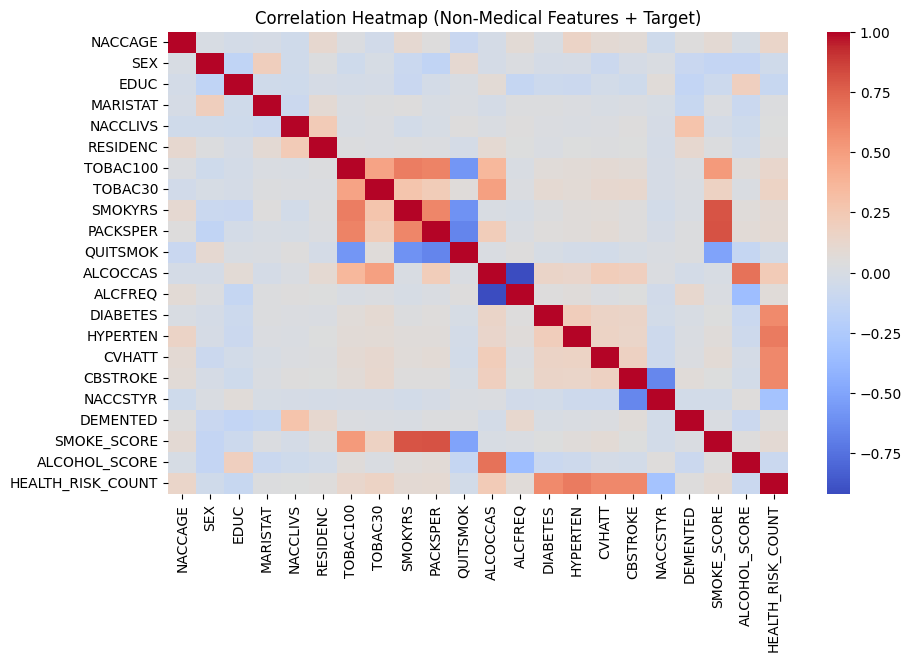

In [58]:
#-----------------------------
# 5. Basic Cleaning & Feature Engineering
# -----------------------------
model_df = df[feature_cols + [target_col]].copy()

# Replace special codes with NaN
model_df = model_df.replace([-4, 88, 99, 999, 9999], np.nan)

# Smoking composite score
if set(["SMOKYRS", "PACKSPER"]).issubset(model_df.columns):
    model_df["SMOKE_SCORE"] = model_df["SMOKYRS"] * model_df["PACKSPER"]

# Alcohol composite score
if set(["ALCOCCAS", "ALCFREQ"]).issubset(model_df.columns):
    model_df["ALCOHOL_SCORE"] = model_df["ALCOCCAS"] * model_df["ALCFREQ"]

# Ensure risk factor columns exist
for c in ["DIABETES", "HYPERTEN", "CVHATT", "CBSTROKE"]:
    if c not in model_df.columns:
        model_df[c] = 0

# Count of health risks
model_df["HEALTH_RISK_COUNT"] = (
    model_df.get("DIABETES", 0) +
    model_df.get("HYPERTEN", 0) +
    model_df.get("CVHATT", 0) +
    model_df.get("CBSTROKE", 0)
)

# Ensure all numeric
for col in model_df.columns:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

# Drop any remaining rows with missing target
model_df = model_df.dropna(subset=[target_col])

print("\nFinal modeling dataframe:", model_df.shape)

# -----------------------------
# 5a. Correlation Heatmap
# -----------------------------
plt.figure(figsize=(10, 6))
corr = model_df.corr()
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap (Non-Medical Features + Target)")
plt.show()

In [59]:
# -----------------------------
# 6. Train-Test Split
# -----------------------------
X = model_df.drop(target_col, axis=1)
y = model_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("\n Train-Test Split Completed")
print("Training shape:", X_train.shape)
print("Testing shape :", X_test.shape)

print("\nTarget Distribution in Train:")
print(y_train.value_counts(normalize=True).rename("Proportion"))

print("\nTarget Distribution in Test:")
print(y_test.value_counts(normalize=True).rename("Proportion"))



 Train-Test Split Completed
Training shape: (156156, 21)
Testing shape : (39040, 21)

Target Distribution in Train:
DEMENTED
0    0.704962
1    0.295038
Name: Proportion, dtype: float64

Target Distribution in Test:
DEMENTED
0    0.704969
1    0.295031
Name: Proportion, dtype: float64


In [60]:
# ======================================================
# 7. Define Models in Pipelines
# ======================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {}

# Logistic Regression (baseline)
models["Logistic Regression"] = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

# Random Forest
models["Random Forest"] = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=3,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

# Gradient Boosting
models["Gradient Boosting"] = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", GradientBoostingClassifier(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.9,
        random_state=RANDOM_STATE
    ))
])

# XGBoost
xgb_clf = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    reg_alpha=0.0,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

models["XGBoost"] = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", xgb_clf)
])

# ------------------------------------------------------
# Display confirmation
# ------------------------------------------------------
print("\n Models Successfully Initialized:\n")
for i, name in enumerate(models.keys(), start=1):
    print(f" {i}. {name}")



 Models Successfully Initialized:

 1. Logistic Regression
 2. Random Forest
 3. Gradient Boosting
 4. XGBoost



Model Performance Comparison:

              Model   CV AUC  Test AUC
      Random Forest 0.783336  0.791902
            XGBoost 0.752602  0.755158
  Gradient Boosting 0.748238  0.750379
Logistic Regression 0.713010  0.715701


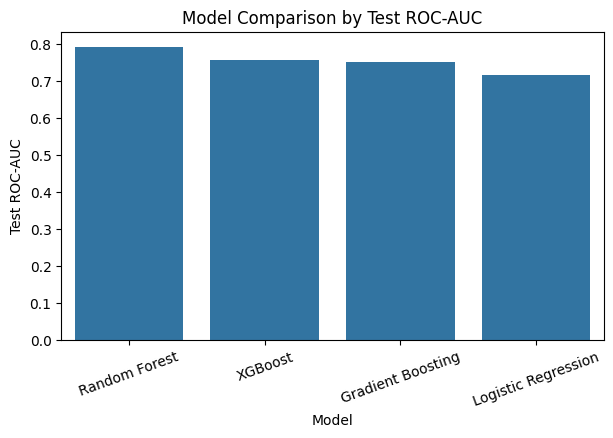

In [61]:
# -----------------------------
# 8. Compare Models
# -----------------------------
results = []
for name, model in models.items():
    cv_scores = cross_val_score(
        model, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1
    )
    model.fit(X_train, y_train)
    prob = model.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test, prob)
    results.append((name, cv_scores.mean(), test_auc))

results_df = pd.DataFrame(results, columns=["Model", "CV AUC", "Test AUC"])
results_df = results_df.sort_values("Test AUC", ascending=False)
print("\nModel Performance Comparison:\n")
print(results_df.to_string(index=False))

best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

plt.figure(figsize=(7,4))
sns.barplot(data=results_df, x="Model", y="Test AUC")
plt.title("Model Comparison by Test ROC-AUC")
plt.ylabel("Test ROC-AUC")
plt.xticks(rotation=20)
plt.show()



Best Model: Random Forest
Test ROC-AUC: 0.7919

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.78      0.81     27522
           1       0.55      0.64      0.59     11518

    accuracy                           0.74     39040
   macro avg       0.69      0.71      0.70     39040
weighted avg       0.75      0.74      0.74     39040


Confusion Matrix:
          Pred 0  Pred 1
Actual 0   21541    5981
Actual 1    4185    7333


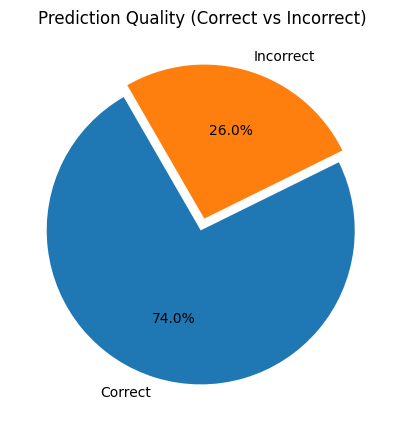

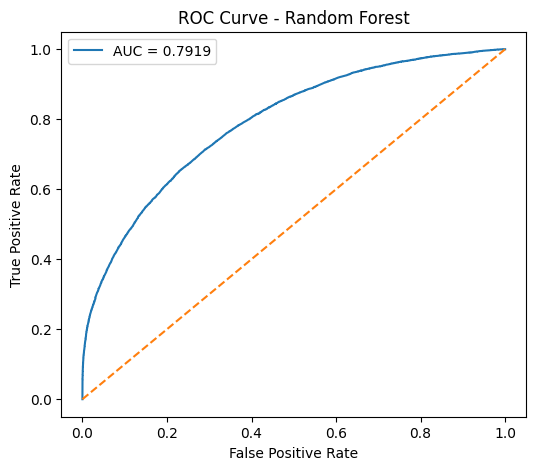

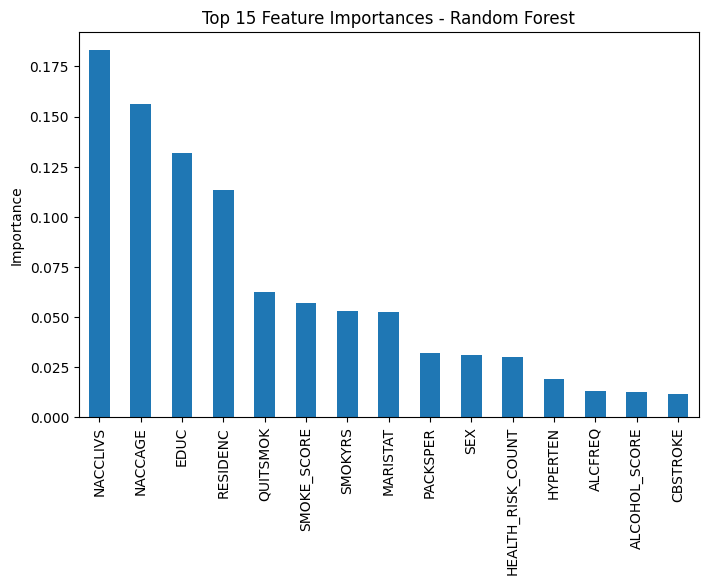

In [62]:
# -----------------------------
# 9. Final Model Evaluation
# -----------------------------
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

pred = best_model.predict(X_test)
prob = best_model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, prob)

print(f"\nBest Model: {best_model_name}")
print(f"Test ROC-AUC: {auc:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred)
cm_df = pd.DataFrame(cm, index=["Actual 0", "Actual 1"], columns=["Pred 0", "Pred 1"])
print("\nConfusion Matrix:")
print(cm_df)

tn, fp, fn, tp = cm.ravel()
correct = tp + tn
incorrect = fp + fn

# Pie Chart (Correct vs Incorrect)
plt.figure(figsize=(5, 5))
plt.pie(
    [correct, incorrect],
    labels=["Correct", "Incorrect"],
    autopct="%1.1f%%",
    startangle=120,
    explode=[0.04, 0.04]
)
plt.title("Prediction Quality (Correct vs Incorrect)")
plt.show()

# -----------------------------
# ROC Curve
# -----------------------------
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, prob)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - {best_model_name}")
plt.legend()
plt.show()

# -----------------------------
# Feature Importance (Explainability)
# -----------------------------
try:
    model_only = best_model.named_steps["clf"]

    # XGBoost & RandomForest compatible
    if hasattr(model_only, "feature_importances_"):
        importances = model_only.feature_importances_
        feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)

        plt.figure(figsize=(8,5))
        feat_imp.head(15).plot(kind="bar")
        plt.title(f"Top 15 Feature Importances - {best_model_name}")
        plt.ylabel("Importance")
        plt.show()
    else:
        print("Feature importance not available for this model.")
except Exception as e:
    print("Feature importance cannot be extracted:", e)


In [63]:
# -----------------------------
# 10. Simple Risk Prediction Function
# -----------------------------
def predict_dementia_risk(input_dict, threshold=0.5):
    x = pd.DataFrame([input_dict])

    # Ensure all required model columns exist
    for col in X_train.columns:
        if col not in x.columns:
            x[col] = np.nan

    # Reorder columns
    x = x[X_train.columns]

    # Predict probability and label
    prob = best_model.predict_proba(x)[:, 1][0]
    label = "At Risk" if prob >= threshold else "Not at Risk"
    return prob, label


# Example prediction
example_person = {
    "NACCAGE": 72, "SEX": 1, "EDUC": 12, "MARISTAT": 2, "NACCLIVS": 1,
    "RESIDENC": 1, "TOBAC100": 1, "TOBAC30": 0, "SMOKYRS": 10,
    "PACKSPER": 1, "QUITSMOK": 60, "ALCOCCAS": 1, "ALCFREQ": 2,
    "DIABETES": 1, "HYPERTEN": 1, "CVHATT": 0, "CBSTROKE": 0, "NACCSTYR": 0,
    "SMOKE_SCORE": 10, "ALCOHOL_SCORE": 2, "HEALTH_RISK_COUNT": 2
}

risk_prob, risk_label = predict_dementia_risk(example_person)
print(f"\nEstimated dementia risk: {risk_prob*100:.2f}%")
print("Risk category:", risk_label)


Estimated dementia risk: 21.62%
Risk category: Not at Risk
